In [21]:
import pandas as pd
import numpy as np
import polars as pl

In [22]:
df = pl.read_csv("../data/3_stock_24hrs.csv")
# Ensure TIME_M is parsed as a datetime column with strict=False to handle invalid formats
df = df.with_columns(
    pl.col("TIME_M").str.to_time(format="%H:%M:%S%.f").alias("TIME_M")
)

# Filter rows between 9:30:00 and 16:00:00
df = df.filter(
    pl.col("TIME_M").is_between(pl.time(9, 30), pl.time(16, 0))
)

df.shape

(20925163, 14)

In [23]:
df['QU_CANCEL'].value_counts()

QU_CANCEL,count
str,u32
null,20925163


# TAQ Quote - Data Dictionary
Exchange that issued the quote (EX)

Bid price (BID)

Bid size in units of trade (BIDSIZ)

Ask price (ASK)

Ask size in units of trade (ASKSIZ)

Condition of quote issued (QU_COND)

Bid exchange (BIDEX)

Ask exchange (ASKEX)

Quote Sequence Number (QU_SEQNUM)

National BBO Indicator (NATBBO_IND)

NASD BBO Indicator (NASDBBO_IND)

Quote Cancel/Correction (QU_CANCEL)

Source of Quote (QU_SOURCE)

## Quote Condition
‘R’ = Regular, two-sided open quote

‘L’ = Closed Market Maker (NASD)

‘Y’ = Regular - One Sided Quote (NASDAQ)

# single exchange
1. find the most liquid exchange ==> narrow apread
    - filter all two-sided quotes and get the narrowest average for each exchange
2. filter for liquid exchange

In [24]:
df['QU_COND'].value_counts()

QU_COND,count
str,u32
"""R""",20925148
"""Y""",15


In [25]:
# Filter for rows where QU_COND is 'R'
filtered_df = df.filter(pl.col("QU_COND") == "R")

# Create a new column 'spread' calculated as ASK - BID
filtered_df = filtered_df.with_columns((pl.col("ASK") - pl.col("BID")).alias("spread"))

# Aggregate by EX column and calculate the average spread
average_spread = (
	filtered_df
	.group_by("EX")
	.agg(pl.col("spread").mean().alias("average_spread"),
        pl.col("spread").count().alias("count"))
    .sort("count")
)

average_spread

EX,average_spread,count
str,f64,u32
"""L""",0.0,2
"""A""",2.037869,7957
"""C""",2.054645,12553
"""H""",0.189494,531024
"""X""",0.423976,623698
…,…,…
"""P""",0.039858,1577094
"""Z""",0.042918,2436341
"""K""",0.035883,2549975


*** EX Q (NASDAQ) has the tightest spread, also has the highest refresh. We assume we can connect directly with NASDAQ ***

for 10 May aapl stock: 
- K (Direct X) performance is very bad
- Z (BATS) performance is still reasonable

In [26]:
filtered_df.filter(pl.col("EX").is_in(["Q"]))['spread'].describe()
# filtered_df.filter(pl.col("EX").is_in(["K"]))['spread'].describe()
# filtered_df.filter(pl.col("EX").is_in(["Z"]))['spread'].describe()

statistic,value
str,f64
"""count""",3.171159e6
"""null_count""",0.0
"""mean""",0.025867
"""std""",0.024503
"""min""",0.01
"""25%""",0.01
"""50%""",0.02
"""75%""",0.03
"""max""",0.61


In [27]:
del filtered_df
del average_spread

# Data prep
1. filter trading hours
2. Nasdaq quotes
3. take twosided quotes only

In [28]:
# filter trading hours
# df = df.with_columns(
#     pl.col("TIME_M").str.to_time(format="%H:%M:%S%.f").alias("TIME_M")
# )
df = df.filter(pl.col("SYM_ROOT") == "AAPL")
df = df.filter(
    pl.col("TIME_M").is_between(pl.time(9, 30), pl.time(16, 0))
)
# Filter for Nasdaq exchange
df = df.filter(pl.col("EX") == "Q")
# Filter for rows where QU_COND is 'R'
df = df.filter(pl.col("QU_COND") == "R")
df.shape

(1905071, 14)

In [29]:
df.describe()

statistic,DATE,TIME_M,EX,BID,BIDSIZ,ASK,ASKSIZ,QU_COND,QU_SEQNUM,NATBBO_IND,QU_CANCEL,QU_SOURCE,SYM_ROOT,SYM_SUFFIX
str,str,str,str,f64,f64,f64,f64,str,f64,f64,str,str,str,str
"""count""","""1905071""","""1905071""","""1905071""",1.905071e6,1.905071e6,1.905071e6,1.905071e6,"""1905071""",1.905071e6,1.905071e6,"""0""","""1905071""","""1905071""","""0"""
"""null_count""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,"""1905071""","""0""","""0""","""1905071"""
"""mean""",null,"""12:36:51.243016""",null,173.444942,7.530051,173.457266,7.288091,null,4.0702e7,1.908896,null,null,null,null
"""std""",null,null,null,0.53389,11.114888,0.533493,7.887325,null,2.0703e7,1.5479,null,null,null,null
"""min""","""2023-05-11""","""09:30:00.000536""","""Q""",172.15,1.0,172.18,1.0,"""R""",801372.0,0.0,null,"""N""","""AAPL""",null
"""25%""",null,"""10:48:50.286842""",null,173.12,3.0,173.14,3.0,null,2.3646552e7,0.0,null,null,null,null
"""50%""",null,"""12:24:06.153371""",null,173.55,6.0,173.56,6.0,null,4.1304458e7,2.0,null,null,null,null
"""75%""",null,"""14:21:54.020992""",null,173.81,10.0,173.82,9.0,null,5.8883933e7,4.0,null,null,null,null
"""max""","""2023-05-11""","""15:59:59.997416""","""Q""",174.56,463.0,174.58,365.0,"""R""",7.5886601e7,4.0,null,"""N""","""AAPL""",null


In [30]:
df['NATBBO_IND'].value_counts()

NATBBO_IND,count
i64,u32
2,759983
0,615934
4,529154


### National Best Bid-Offer (NBBO) - Legend 
‘0’ = No National BBO change - Current quote does not affect the BBO. No National appendage is required.

‘1’ = No National BBO Can be Calculated- The National BBO cannot be calculated therefore vendors should show National BBO fields as blank. No Appendage is required.

‘2’ = Short Form National BBO Appendage Attached – A new National BBO was generated as a result of the UTP participant’s quote update and the new information is contained in the short form appendage (NBBO FILE)

‘3’ = Long Format of National BBO Appendage - A new National BBO is generated and the new BBO information is contained in the Long National BBO appendage (NBBO FILE)

‘4’ = Quote Contains all NASD BBO Information - Current quote is itself the new NASD BBO. No NASD appendage is required.

---
In the case above, I will track all bid offer and size regardless of NATBBO indicator

In [31]:
df['QU_COND'].value_counts()

QU_COND,count
str,u32
"""R""",1905071


In [32]:
df.columns

['DATE',
 'TIME_M',
 'EX',
 'BID',
 'BIDSIZ',
 'ASK',
 'ASKSIZ',
 'QU_COND',
 'QU_SEQNUM',
 'NATBBO_IND',
 'QU_CANCEL',
 'QU_SOURCE',
 'SYM_ROOT',
 'SYM_SUFFIX']

# Try OBI strategy

In [33]:
class OBIVWAPStrategy:
    def __init__(self, vwap_window: int, obi_threshold: float, initial_cash: float = 100_000):
        self.vwap_window = vwap_window
        self.obi_threshold = obi_threshold
        self.cash = initial_cash
        self.position = 0
        self.account_balance = []

    def calculate_vwap(self, df: pl.DataFrame) -> pl.DataFrame:
        # Calculate MID_PRICE
        df = df.with_columns(
            ((pl.col("BID") + pl.col("ASK")) / 2).alias("MID_PRICE")
        )
        # Calculate Volume
        df = df.with_columns(
            (pl.col("BIDSIZ") + pl.col("ASKSIZ")).alias("Volume")
        )
        # Calculate VWAP using rolling window
        df = df.with_columns(
            (
                (pl.col("MID_PRICE") * pl.col("Volume"))
                .rolling_sum(window_size=self.vwap_window)
                / pl.col("Volume").rolling_sum(window_size=self.vwap_window)
            ).alias("VWAP")
        )
        return df

    def calculate_obi(self, df: pl.DataFrame) -> pl.DataFrame:
        # Calculate Order Book Imbalance (OBI)
        df = df.with_columns(
            (
                (pl.col("BIDSIZ") - pl.col("ASKSIZ"))
                / (pl.col("BIDSIZ") + pl.col("ASKSIZ"))
            ).alias("OBI")
        )
        return df

    def generate_signals(self, df: pl.DataFrame) -> pl.DataFrame:
        # Calculate VWAP and OBI
        df = self.calculate_vwap(df)
        df = self.calculate_obi(df)

        # Generate signals based on OBI threshold
        df = df.with_columns(
            pl.when(pl.col("OBI") > self.obi_threshold)
            .then(1)  # Buy signal
            .when(pl.col("OBI") < -self.obi_threshold)
            .then(-1)  # Sell signal
            .otherwise(0)  # No signal
            .alias("Signal")
        )
        return df

    def backtest(self, df: pl.DataFrame) -> pl.DataFrame:
        # Initialize account balance tracking
        account_balance = []

        # Iterate over rows to simulate trading
        for row in df.iter_rows(named=True):
            if row["Signal"] == 1 and self.cash >= row["ASK"] * 100 and self.position <= 1:
                # Buy 100 shares
                self.position = 100
                self.cash -= row["ASK"] * 100
            elif row["Signal"] == -1 and self.position > -1:
                # Sell 100 shares
                self.position = -100
                self.cash += row["BID"] * 100
            elif row["Signal"] == 0 and self.position != 0:
                # Close position
                if self.position > 0:
                    self.cash += row["BID"] * self.position
                else:
                    self.cash -= row["ASK"] * abs(self.position)
                self.position = 0

            # Record account balance
            account_balance.append(self.cash + self.position * (row["ASK"] if self.position > 0 else row["BID"]))

        # Add account balance to the DataFrame
        df = df.with_columns(pl.Series("Account_Balance", account_balance))
        return df

In [34]:
strategy = OBIVWAPStrategy(vwap_window=50, obi_threshold=0.2)
signal_data = strategy.generate_signals(df)
backtest_data = strategy.backtest(signal_data)

print(backtest_data.head())


shape: (5, 20)
┌────────────┬────────────────────┬─────┬────────┬───┬──────┬─────┬────────┬─────────────────┐
│ DATE       ┆ TIME_M             ┆ EX  ┆ BID    ┆ … ┆ VWAP ┆ OBI ┆ Signal ┆ Account_Balance │
│ ---        ┆ ---                ┆ --- ┆ ---    ┆   ┆ ---  ┆ --- ┆ ---    ┆ ---             │
│ str        ┆ time               ┆ str ┆ f64    ┆   ┆ f64  ┆ f64 ┆ i32    ┆ f64             │
╞════════════╪════════════════════╪═════╪════════╪═══╪══════╪═════╪════════╪═════════════════╡
│ 2023-05-11 ┆ 09:30:00.000536359 ┆ Q   ┆ 173.77 ┆ … ┆ null ┆ 0.8 ┆ 1      ┆ 100000.0        │
│ 2023-05-11 ┆ 09:30:00.004163035 ┆ Q   ┆ 173.79 ┆ … ┆ null ┆ 0.5 ┆ 1      ┆ 100000.0        │
│ 2023-05-11 ┆ 09:30:00.072729735 ┆ Q   ┆ 173.79 ┆ … ┆ null ┆ 0.5 ┆ 1      ┆ 99998.0         │
│ 2023-05-11 ┆ 09:30:00.072824334 ┆ Q   ┆ 173.79 ┆ … ┆ null ┆ 0.5 ┆ 1      ┆ 100000.0        │
│ 2023-05-11 ┆ 09:30:00.134316169 ┆ Q   ┆ 173.8  ┆ … ┆ null ┆ 0.0 ┆ 0      ┆ 99988.0         │
└────────────┴────────────────────┴

In [35]:
backtest_data.tail(10)

DATE,TIME_M,EX,BID,BIDSIZ,ASK,ASKSIZ,QU_COND,QU_SEQNUM,NATBBO_IND,QU_CANCEL,QU_SOURCE,SYM_ROOT,SYM_SUFFIX,MID_PRICE,Volume,VWAP,OBI,Signal,Account_Balance
str,time,str,f64,i64,f64,i64,str,i64,i64,str,str,str,str,f64,i64,f64,f64,i32,f64
"""2023-05-11""",15:59:59.915779893,"""Q""",173.81,147,173.83,2,"""R""",75885230,0,null,"""N""","""AAPL""",null,173.82,149,173.821959,0.973154,1,2.557127e6
"""2023-05-11""",15:59:59.917404116,"""Q""",173.81,147,173.84,115,"""R""",75885279,0,null,"""N""","""AAPL""",null,173.825,262,173.822371,0.122137,0,2.557125e6
"""2023-05-11""",15:59:59.943797296,"""Q""",173.81,168,173.84,115,"""R""",75885618,4,null,"""N""","""AAPL""",null,173.825,283,173.822744,0.187279,0,2.557125e6
"""2023-05-11""",15:59:59.944540339,"""Q""",173.81,168,173.84,143,"""R""",75885626,4,null,"""N""","""AAPL""",null,173.825,311,173.82307,0.080386,0,2.557125e6
"""2023-05-11""",15:59:59.970278384,"""Q""",173.81,166,173.84,143,"""R""",75886108,4,null,"""N""","""AAPL""",null,173.825,309,173.82334,0.074434,0,2.557125e6
"""2023-05-11""",15:59:59.970280325,"""Q""",173.81,165,173.84,143,"""R""",75886109,4,null,"""N""","""AAPL""",null,173.825,308,173.823577,0.071429,0,2.557125e6
"""2023-05-11""",15:59:59.970540590,"""Q""",173.81,168,173.84,143,"""R""",75886110,4,null,"""N""","""AAPL""",null,173.825,311,173.823773,0.080386,0,2.557125e6
"""2023-05-11""",15:59:59.985241406,"""Q""",173.81,167,173.84,143,"""R""",75886387,4,null,"""N""","""AAPL""",null,173.825,310,173.823935,0.077419,0,2.557125e6
"""2023-05-11""",15:59:59.987595476,"""Q""",173.81,164,173.84,143,"""R""",75886429,4,null,"""N""","""AAPL""",null,173.825,307,173.824072,0.068404,0,2.557125e6


In [36]:
backtest_data["Account_Balance"].describe()

statistic,value
str,f64
"""count""",1.905071e6
"""null_count""",0.0
"""mean""",1.5835e6
"""std""",671597.305423
"""min""",4693.0
"""25%""",1.153933e6
"""50%""",1.555837e6
"""75%""",2.02547e6
"""max""",3.217205e6


In [37]:
backtest_data['OBI'].sum()

25187.72615595779

In [38]:
backtest_data.tail(5)

DATE,TIME_M,EX,BID,BIDSIZ,ASK,ASKSIZ,QU_COND,QU_SEQNUM,NATBBO_IND,QU_CANCEL,QU_SOURCE,SYM_ROOT,SYM_SUFFIX,MID_PRICE,Volume,VWAP,OBI,Signal,Account_Balance
str,time,str,f64,i64,f64,i64,str,i64,i64,str,str,str,str,f64,i64,f64,f64,i32,f64
"""2023-05-11""",15:59:59.970280325,"""Q""",173.81,165,173.84,143,"""R""",75886109,4,null,"""N""","""AAPL""",null,173.825,308,173.823577,0.071429,0,2.557125e6
"""2023-05-11""",15:59:59.970540590,"""Q""",173.81,168,173.84,143,"""R""",75886110,4,null,"""N""","""AAPL""",null,173.825,311,173.823773,0.080386,0,2.557125e6
"""2023-05-11""",15:59:59.985241406,"""Q""",173.81,167,173.84,143,"""R""",75886387,4,null,"""N""","""AAPL""",null,173.825,310,173.823935,0.077419,0,2.557125e6
"""2023-05-11""",15:59:59.987595476,"""Q""",173.81,164,173.84,143,"""R""",75886429,4,null,"""N""","""AAPL""",null,173.825,307,173.824072,0.068404,0,2.557125e6
"""2023-05-11""",15:59:59.997416331,"""Q""",173.81,197,173.84,143,"""R""",75886601,4,null,"""N""","""AAPL""",null,173.825,340,173.824194,0.158824,0,2.557125e6


In [39]:
backtest_data

DATE,TIME_M,EX,BID,BIDSIZ,ASK,ASKSIZ,QU_COND,QU_SEQNUM,NATBBO_IND,QU_CANCEL,QU_SOURCE,SYM_ROOT,SYM_SUFFIX,MID_PRICE,Volume,VWAP,OBI,Signal,Account_Balance
str,time,str,f64,i64,f64,i64,str,i64,i64,str,str,str,str,f64,i64,f64,f64,i32,f64
"""2023-05-11""",09:30:00.000536359,"""Q""",173.77,9,173.92,1,"""R""",801372,2,null,"""N""","""AAPL""",null,173.845,10,null,0.8,1,100000.0
"""2023-05-11""",09:30:00.004163035,"""Q""",173.79,3,173.92,1,"""R""",801632,2,null,"""N""","""AAPL""",null,173.855,4,null,0.5,1,100000.0
"""2023-05-11""",09:30:00.072729735,"""Q""",173.79,3,173.9,1,"""R""",805152,0,null,"""N""","""AAPL""",null,173.845,4,null,0.5,1,99998.0
"""2023-05-11""",09:30:00.072824334,"""Q""",173.79,3,173.92,1,"""R""",805160,0,null,"""N""","""AAPL""",null,173.855,4,null,0.5,1,100000.0
"""2023-05-11""",09:30:00.134316169,"""Q""",173.8,1,173.92,1,"""R""",809555,2,null,"""N""","""AAPL""",null,173.86,2,null,0.0,0,99988.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2023-05-11""",15:59:59.970280325,"""Q""",173.81,165,173.84,143,"""R""",75886109,4,null,"""N""","""AAPL""",null,173.825,308,173.823577,0.071429,0,2.557125e6
"""2023-05-11""",15:59:59.970540590,"""Q""",173.81,168,173.84,143,"""R""",75886110,4,null,"""N""","""AAPL""",null,173.825,311,173.823773,0.080386,0,2.557125e6
"""2023-05-11""",15:59:59.985241406,"""Q""",173.81,167,173.84,143,"""R""",75886387,4,null,"""N""","""AAPL""",null,173.825,310,173.823935,0.077419,0,2.557125e6


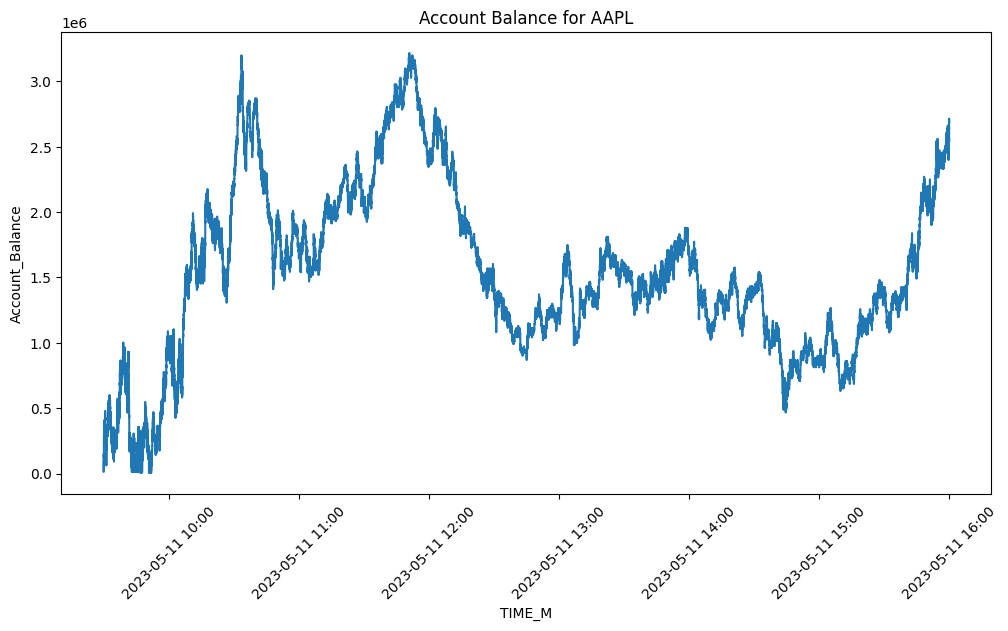

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Convert to pandas
backtest_data = backtest_data.with_columns(
    (pl.col("DATE").cast(pl.Utf8) + " " + pl.col("TIME_M").cast(pl.Utf8))
    .str.strptime(pl.Datetime("ns"), format="%Y-%m-%d %H:%M:%S%.f")
    .alias("TIME_M")
)

pdf = backtest_data.to_pandas()


# Plot
for ticker in set(pdf['SYM_ROOT']):
    ticker_df = pdf[pdf['SYM_ROOT'] == ticker]
    plt.figure(figsize=(12, 6))
    plt.plot(ticker_df["TIME_M"], ticker_df["Account_Balance"])
    plt.xlabel("TIME_M")
    plt.ylabel("Account_Balance")
    plt.title(f"Account Balance for {ticker}")
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    plt.xticks(rotation=45)
    plt.show()